# Projet Analyse de Données — Prédiction des Prix Airbnb

**Objectif :** Prédire le logarithme du prix de location (`log_price`) d'un logement Airbnb à partir de ses caractéristiques textuelles et numériques.

Ce notebook est organisé en deux grandes parties :
1. **Exploration qualitative des données (EDA)** - comprendre la base, visualiser les distributions et justifier nos choix de modélisation.
2. **Prédiction** - feature engineering, comparaison de modèles et génération du fichier final.

## Sommaire
- [Partie 1 : Exploration des Données](#eda)
  - [1.1 Présentation de la base](#pres)
  - [1.2 Variable cible : distribution de `log_price`](#distrib)
  - [1.3 Prix par ville et par type de logement](#ville)
  - [1.4 Carte géographique des prix](#carte)
  - [1.5 Corrélations avec le prix](#corr)
  - [1.6 Analyse des équipements (`amenities`)](#amenities)
  - [1.7 Valeurs manquantes](#missing)
- [Partie 2 : Prédiction](#pred)
  - [2.0 Baseline naïve](#baseline)
  - [2.1 Version 1 : Modèle simple (LinearSVR)](#v1)
  - [2.2 Version 2 : Modèle intermédiaire (RandomForest + XGBoost)](#v2)
  - [2.3 Version 3 : Modèle final optimisé (XGBoost + Early Stopping)](#v3)
  - [2.4 Récapitulatif des performances](#recap)
  - [2.5 Génération du fichier de prédiction](#submit)

## Imports et chargement des données

In [58]:
!pip install category_encoders

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from category_encoders import TargetEncoder

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Chargement des données
train = pd.read_csv("airbnb_train.csv")
test  = pd.read_csv("airbnb_test.csv")

print(f"Train : {train.shape[0]:,} lignes et {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes  et {test.shape[1]} colonnes")

Train : 22,234 lignes et 28 colonnes
Test  : 51,877 lignes  et 27 colonnes


---
<a id="eda"></a>
# Partie 1 : Exploration Qualitative des Données (EDA)
L'exploration est nécessaire pour choisir les caractéristiques de feature engineering de la partie prédiction.

<a id="pres"></a>
## 1.1 Présentation de la base
En premier, on cherche à comprendre le dataset qui nous a été donné. On commence par regarder à quoi il ressemble : ses colonnes, ses types, et quelques exemples de lignes.

In [60]:
# Aperçu des 5 premières lignes
train.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [61]:
# Types de chaque colonne
train.dtypes.to_frame("dtype").T

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
dtype,int64,float64,object,object,object,int64,float64,object,object,bool,...,object,float64,float64,object,object,int64,float64,object,float64,float64


In [62]:
# Statistiques descriptives des colonnes numériques
train.describe().round(2)

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,22234.00,22234.00,22234.00,22183.00,22234.00,22234.00,22234.00,17256.00,22208.00,22199.00
mean,11222692.18,4.78,3.16,1.24,38.46,-92.27,20.67,94.07,1.26,1.71
std,6080480.28,0.72,2.14,0.59,3.07,21.67,37.18,7.78,0.85,1.25
min,3362.00,2.30,1.00,0.00,33.34,-122.51,0.00,20.00,0.00,0.00
25%,6202924.25,4.32,2.00,1.00,34.14,-118.34,1.00,92.00,1.00,1.00
50%,12174250.00,4.70,2.00,1.00,40.66,-76.99,6.00,96.00,1.00,1.00
75%,16395021.50,5.22,4.00,1.00,40.75,-73.95,23.00,100.00,1.00,2.00
max,21204503.00,7.60,16.00,8.00,42.39,-70.99,505.00,100.00,10.00,18.00


**Observations :**
- La variable cible `log_price` est continue et centrée autour de ~4.7 (soit ~$110 en prix réel).
- `accommodates`, `bedrooms`, `beds`, `bathrooms` sont des entiers qui décrivent la taille du logement.
- `amenities` est une chaîne de texte brute listant les équipements.
- Plusieurs colonnes avec des types object (`room_type`, `property_type`, `city`, `neighbourhood`, `cancellation_policy`) devront être encodées.

<a id="distrib"></a>
## 1.2 Distribution de la variable cible : `log_price`
Nous nous sommes ensuite demander pourquoi est ce que l'on cherchait à prédire le logarithme du prix plutôt que le prix réel.

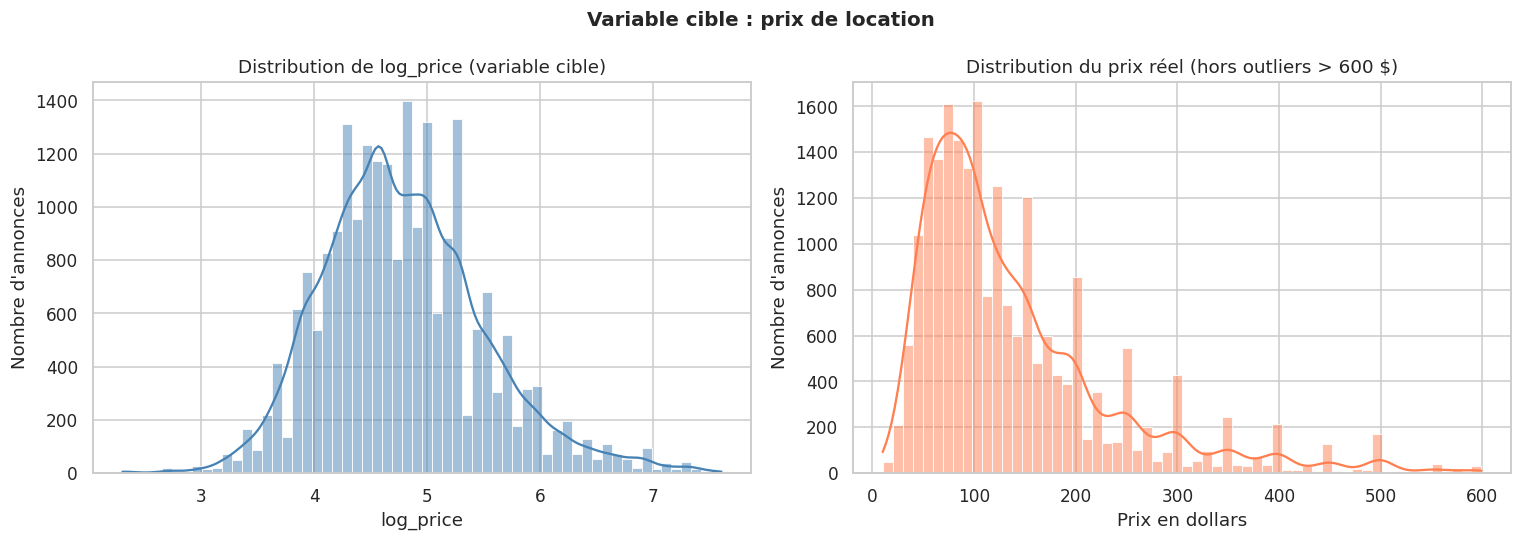

Prix moyen (réel) : $161
Prix médian (réel) : $110
log_price moyen : 4.783 | écart-type : 0.719


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + KDE du log_price
sns.histplot(train["log_price"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de log_price (variable cible)")
axes[0].set_xlabel("log_price")
axes[0].set_ylabel("Nombre d'annonces")

# Même chose mais en prix réel (exp)
real_prices = np.exp(train["log_price"])
sns.histplot(real_prices[real_prices < 600], bins=60, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribution du prix réel (hors outliers > 600 $)")
axes[1].set_xlabel("Prix en dollars")
axes[1].set_ylabel("Nombre d'annonces")

plt.suptitle("Variable cible : prix de location", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Prix moyen (réel) : ${np.exp(train['log_price']).mean():.0f}")
print(f"Prix médian (réel) : ${np.exp(train['log_price']).median():.0f}")
print(f"log_price moyen : {train['log_price'].mean():.3f} | écart-type : {train['log_price'].std():.3f}")

**Conclusion :** `log_price` suit une distribution proche de la normale, c'est pourquoi on travaille sur le logarithme du prix et non le prix brut. Cela rend les modèles de régression plus efficaces et donc notre prédiction aura plus de chance de se rapprocher de la vraie valeur.

<a id="ville"></a>
## 1.3 Prix par ville et par type de logement
Nous nous sommes ensuite demander quels étaient les facteurs qualitatifs les plus importants (et déterminants) dans notre dataset. Nous avons tout de suite pensé à la ville et le type de logement.

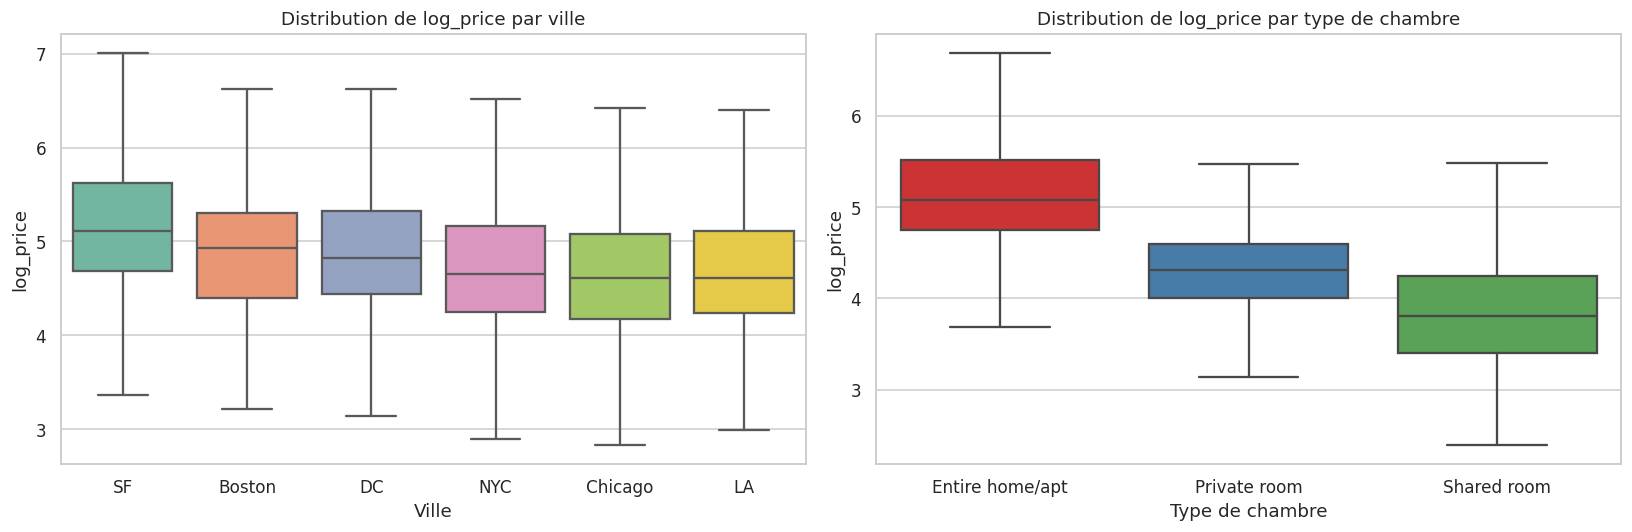

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot prix par ville
city_order = train.groupby("city")["log_price"].median().sort_values(ascending=False).index
sns.boxplot(data=train, x="city", y="log_price", order=city_order,
            palette="Set2", ax=axes[0], showfliers=False)
axes[0].set_title("Distribution de log_price par ville")
axes[0].set_xlabel("Ville")
axes[0].set_ylabel("log_price")

# Boxplot prix par room_type
room_order = train.groupby("room_type")["log_price"].median().sort_values(ascending=False).index
sns.boxplot(data=train, x="room_type", y="log_price", order=room_order,
            palette="Set1", ax=axes[1], showfliers=False)
axes[1].set_title("Distribution de log_price par type de chambre")
axes[1].set_xlabel("Type de chambre")
axes[1].set_ylabel("log_price")

plt.tight_layout()
plt.show()

In [65]:
# Prix moyen par ville (tableau)
city_stats = (train.groupby("city")["log_price"]
              .agg(["mean", "median", "count"])
              .sort_values("median", ascending=False)
              .rename(columns={"mean": "Moyenne", "median": "Médiane", "count": "Nb annonces"}))
city_stats["Prix médian réel ($)"] = np.exp(city_stats["Médiane"]).round(0).astype(int)
print(city_stats.round(3))

         Moyenne  Médiane  Nb annonces  Prix médian réel ($)
city                                                        
SF         5.185    5.106         1924                   165
Boston     4.878    4.934         1028                   139
DC         4.965    4.828         1744                   125
NYC        4.725    4.654         9739                   105
Chicago    4.653    4.605         1127                   100
LA         4.713    4.605         6672                   100


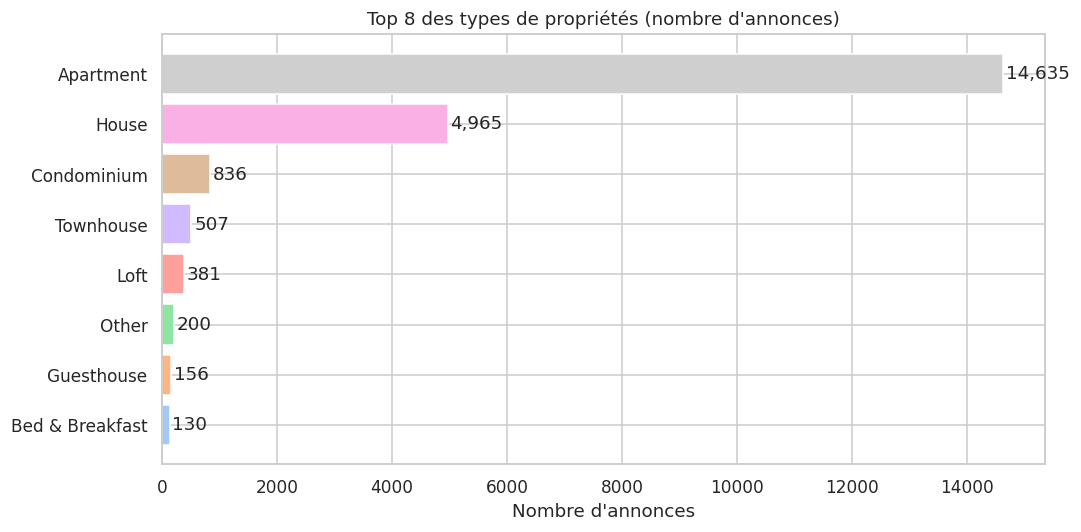

In [66]:
# Proportion des types de logements (property_type)
top_props = train["property_type"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_props.index[::-1], top_props.values[::-1], color=sns.color_palette("pastel"))
ax.set_title("Top 8 des types de propriétés (nombre d'annonces)")
ax.set_xlabel("Nombre d'annonces")
for bar, val in zip(bars, top_props.values[::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center")
plt.tight_layout()
plt.show()

**Conclusions clées :**
- **San Francisco et New York** ont les prix les plus élevés et la variable `city` est bien un prédicteur très fort.
- Un **logement entier** coûte significativement plus qu'une chambre privée, qui coûte elle-même plus qu'une chambre partagée.
- **Apartment** domine largement la base (>50%), suivi de **House**.
Ces variables seront encodées avec le **Target Encoding** (remplacement par le prix moyen du groupe).

<a id="carte"></a>
## 1.4 Carte géographique des prix
Notre dataset contient aussi les coordonnées GPS (`latitude` / `longitude`). On a vu juste avant que les prix à New York étaient élevés mais on peut se demander si la répartition des prix à New York ne dépend pas aussi des quartiers. En effet, dans  l'immobilier, l'emplacement est souvent un critère très important.

Mettons ces données sous forme visuelle en traçant une carte des logements, colorée par leur prix :

/tmp/ipykernel_337/3478131812.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(sc, ax=axes[0], label="log_price")
/tmp/ipykernel_337/3478131812.py:18: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(sc2, ax=axes[1], label="log_price")


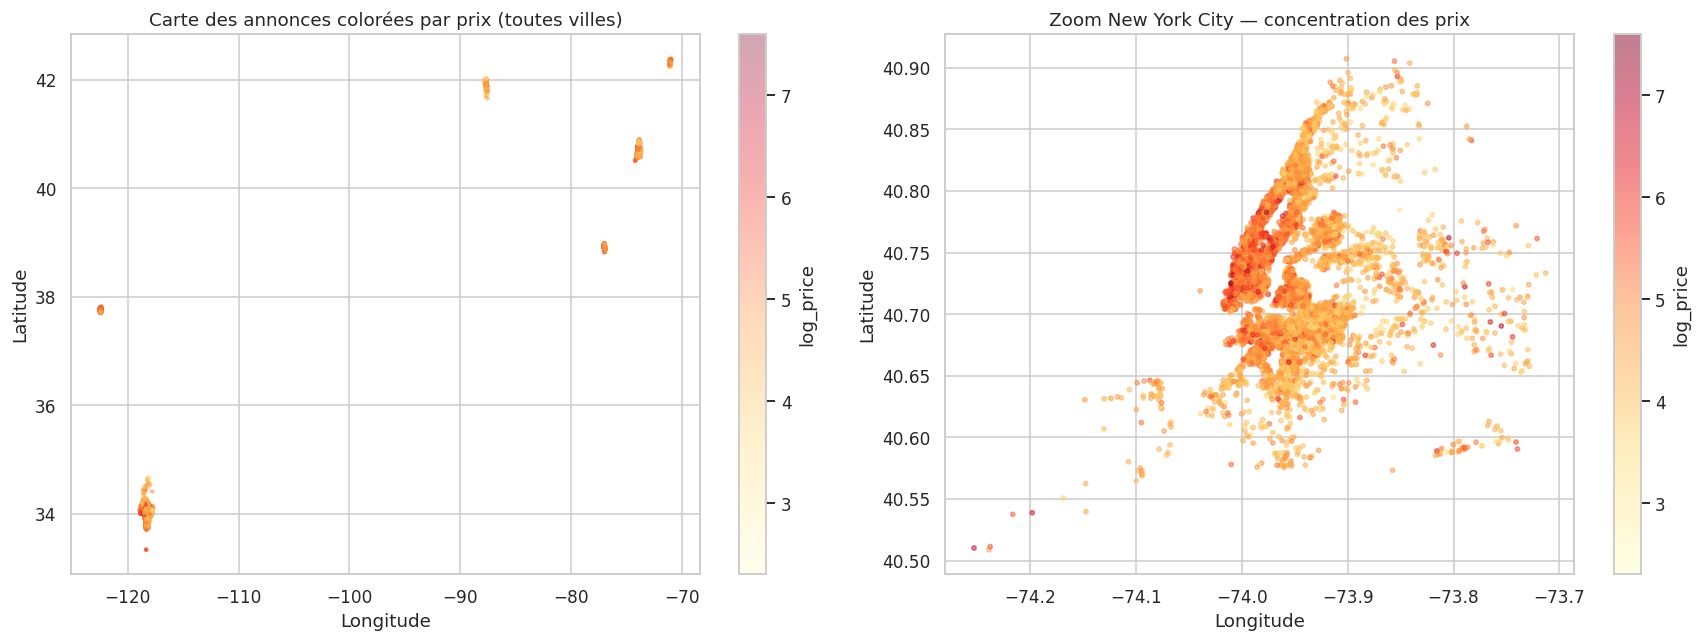

In [67]:
# On filtre les outliers GPS évidents
df_map = train[(train["latitude"].between(25, 50)) & (train["longitude"].between(-125, -65))].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Carte globale (toutes villes)
sc = axes[0].scatter(df_map["longitude"], df_map["latitude"],
                     c=df_map["log_price"], cmap="YlOrRd", alpha=0.35, s=4)
plt.colorbar(sc, ax=axes[0], label="log_price")
axes[0].set_title("Carte des annonces colorées par prix (toutes villes)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Zoom NYC
nyc = df_map[df_map["city"] == "NYC"]
sc2 = axes[1].scatter(nyc["longitude"], nyc["latitude"],
                      c=nyc["log_price"], cmap="YlOrRd", alpha=0.5, s=8)
plt.colorbar(sc2, ax=axes[1], label="log_price")
axes[1].set_title("Zoom New York City — concentration des prix")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

**Conclusion :** La carte révèle clairement des **zones de prix élevées** (Manhattan, centre de San Francisco...). La géographie est donc un signal fort.

Pour la suite on décide alors de créer la feature `dist_center` qui représente la distance de chaque logement au centre de sa ville.

<a id="corr"></a>
## 1.5 Corrélations des variables numériques avec `log_price`
On va maintenant examiner les relations linéaires entre les variables quantitatives et log_price afin de déterminer un ordre d'importance en terme de corrélation des variables avec log_price et ainsi justifier celles que nous garderons dans le modèle final.

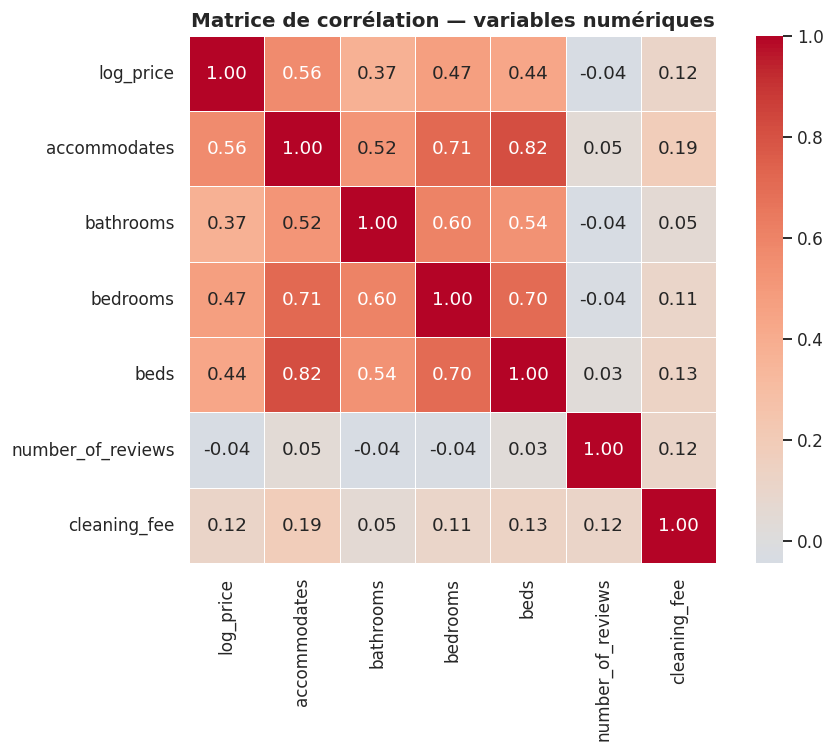

In [68]:
num_cols = ["log_price", "accommodates", "bathrooms", "bedrooms",
             "beds", "number_of_reviews", "cleaning_fee"]
corr_matrix = train[num_cols].corr()

plt.figure(figsize=(9, 7))
#tout ca au lieu de la petite ligne en comm
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
# sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation — variables numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

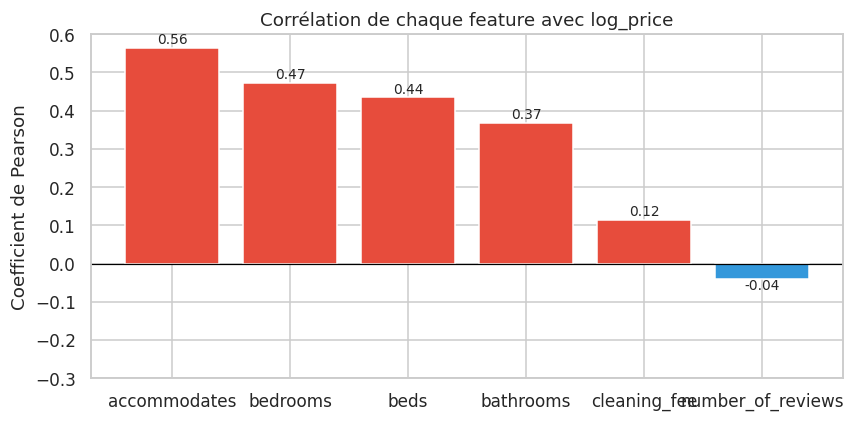

In [69]:
# Corrélation de chaque variable avec log_price (triée)
corr_with_price = corr_matrix["log_price"].drop("log_price").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_with_price]
ax.bar(corr_with_price.index, corr_with_price.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Corrélation de chaque feature avec log_price")
ax.set_ylabel("Coefficient de Pearson")
ax.set_ylim(-0.3, 0.6)
for i, v in enumerate(corr_with_price.values):
    ax.text(i, v + 0.01 if v >= 0 else v - 0.03, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Conclusions :**
- `accommodates`, `bedrooms` et `bathrooms` ont les corrélations les plus fortes (>0.35) avec le prix.
- `cleaning_fee` est aussi positivement corrélé (les logements haut de gamme facturent plus les frais de ménage).
- `number_of_reviews` a une corrélation quasi nulle.
- On note que `beds` et `bedrooms` sont très certainement corrélés entre eux (multicolinéarité).

<a id="amenities"></a>
## 1.6 Analyse des équipements (`amenities`)
La colonne `amenities` est une chaîne de texte brute. On cherche à déterminer dans cette colonne quels équipements sont les plus fréquents et lesquels sont corrélés au prix.

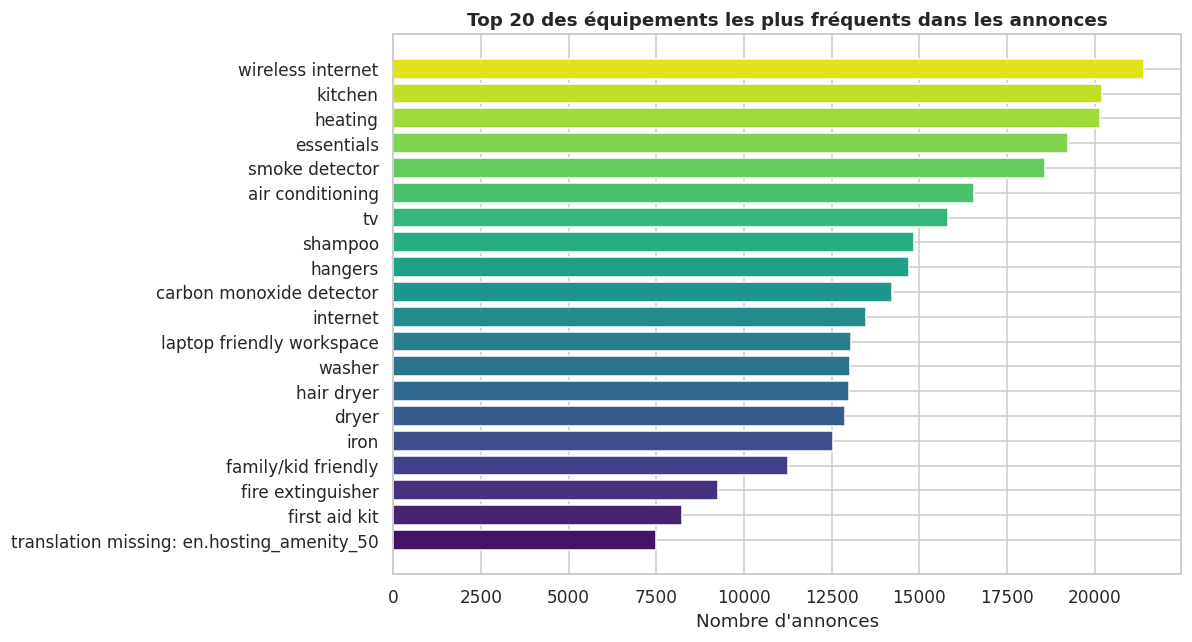

In [70]:
# On parse la colonne amenities pour extraire les équipements les plus fréquents
from collections import Counter

all_amenities = []
for row in train["amenities"].dropna():
    items = [x.strip().strip('"{}').lower() for x in row.split(",")]
    all_amenities.extend(items)

top_amenities = Counter(all_amenities).most_common(20)
amenity_names = [a[0] for a in top_amenities]
amenity_counts = [a[1] for a in top_amenities]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(amenity_names[::-1], amenity_counts[::-1], color=sns.color_palette("viridis", 20))
ax.set_title("Top 20 des équipements les plus fréquents dans les annonces", fontweight="bold")
ax.set_xlabel("Nombre d'annonces")
plt.tight_layout()
plt.show()

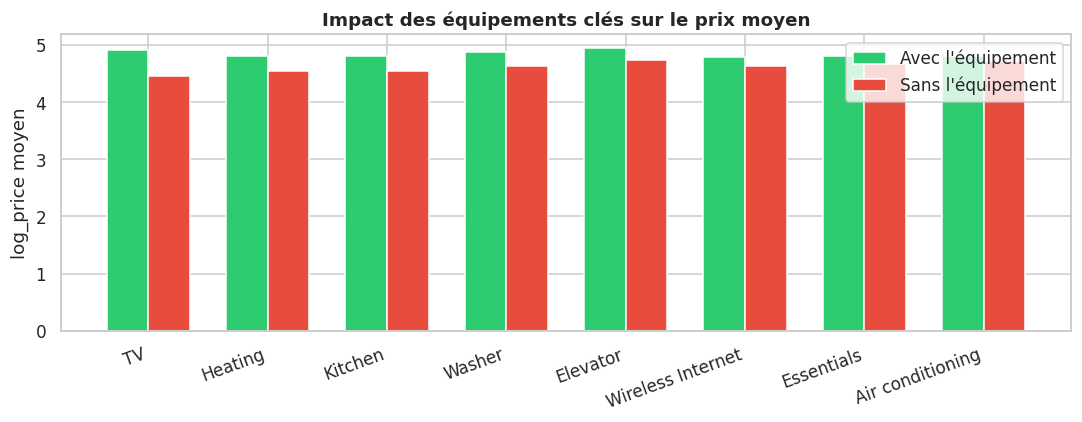

       Équipement    Écart  % annonces
               TV 0.442817   72.762436
          Heating 0.271816   90.653953
          Kitchen 0.269904   90.847351
           Washer 0.247602   59.503463
         Elevator 0.203637   23.077269
Wireless Internet 0.154980   96.248988
       Essentials 0.125410   86.471170
 Air conditioning 0.085088   74.529999


In [71]:
# Impact de quelques équipements clés sur le prix
key_amenities = {
    "has_ac":       "Air conditioning",
    "has_wifi":     "Wireless Internet",
    "has_kitchen":  "Kitchen",
    "has_tv":       "TV",
    "has_elevator": "Elevator",
    "has_essentials":  "Essentials",
    "has_heating":  "Heating",
    "has_washer":  "Washer",
}

impact_data = []
for col_name, keyword in key_amenities.items():
    train[col_name] = train["amenities"].str.contains(keyword, case=False, na=False).astype(int)
    mean_with    = train[train[col_name] == 1]["log_price"].mean()
    mean_without = train[train[col_name] == 0]["log_price"].mean()
    impact_data.append({"Équipement": keyword, "Avec": mean_with, "Sans": mean_without,
                        "Écart": mean_with - mean_without,
                        "% annonces": train[col_name].mean() * 100})

df_impact = pd.DataFrame(impact_data).sort_values("Écart", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_impact))
width = 0.35
ax.bar(x - width/2, df_impact["Avec"],   width, label="Avec l'équipement",    color="#2ecc71")
ax.bar(x + width/2, df_impact["Sans"],   width, label="Sans l'équipement",   color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(df_impact["Équipement"], rotation=20, ha="right")
ax.set_ylabel("log_price moyen")
ax.set_title("Impact des équipements clés sur le prix moyen", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(df_impact[["Équipement", "Écart", "% annonces"]].to_string(index=False))

**Conclusions :**
- La **télé** et le **chauffage** ont l'impact positif le plus marqué sur le prix (+0.44 et +0.27 log).
- Le **Wifi** est quasi universel (>95% des annonces), donc peu discriminant (son importance sera faible).

Nous créerons des colonnes binaires pour simplifier :`has_heating`, `has_wifi`, `has_tv`, `has_elevator`, `has_kitchen`, `has_washer`.

<a id="missing"></a>
## 1.7 Analyse des valeurs manquantes
Il est crucial d'identifier les colonnes incomplètes avant de modéliser.

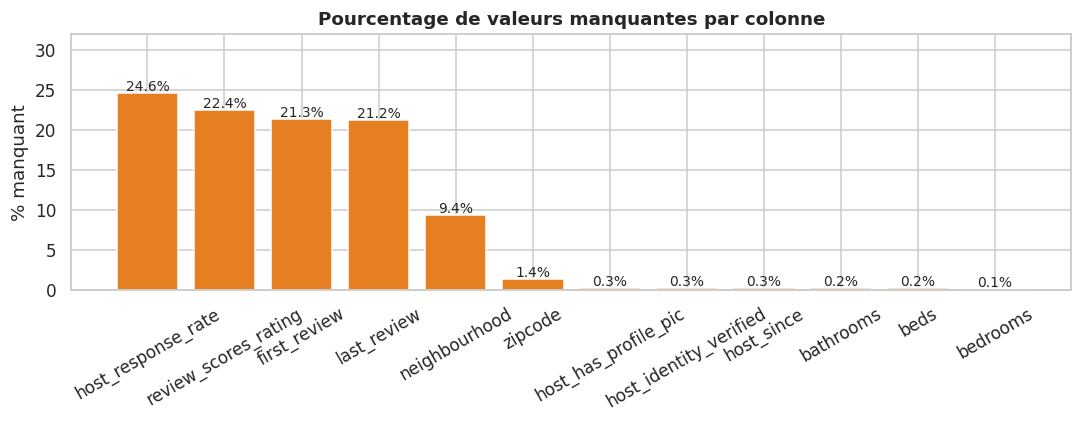

Stratégie de remplacement :
  - bathrooms/bedrooms/beds -> médiane
  - cleaning_fee -> 0 (absence = pas de frais)
  - host_response_rate / review_scores_rating / first_review / last_review -> non utilisées
    (trop de valeurs manquantes >20%, ou non pertinentes pour le prix)


In [72]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct_missing = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(missing.index, pct_missing.values, color="#e67e22")
ax.set_title("Pourcentage de valeurs manquantes par colonne", fontweight="bold")
ax.set_ylabel("% manquant")
ax.set_ylim(0, pct_missing.max() * 1.3)
ax.tick_params(axis="x", rotation=30)
for bar, pct in zip(bars, pct_missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Stratégie de remplacement :")
print("  - bathrooms/bedrooms/beds -> médiane")
print("  - cleaning_fee -> 0 (absence = pas de frais)")
print("  - host_response_rate / review_scores_rating / first_review / last_review -> non utilisées")
print("    (trop de valeurs manquantes >20%, ou non pertinentes pour le prix)")

**Synthèse de l'Exploration :**

Les variables `room_type`, `city`, `neighbourhood` ont une très grande importance.

`accommodates`, `bedrooms`, `bathrooms` ont aussi un grand impact.

`cleaning_fee`, `dist_center` peuvent aussi être utiles pour améliorer nos prédictions.

Pour la colonne des équipements (`amenities`) nous avons décidé de l'extraire pour la transformer en colonnes binaires plus simples à manipuler

<a id="pred"></a>
# Partie 2 : Prédiction

Nous avons laissé une trace de chaque modèle testé et de leur résultat.
Pour les comparer, on utilise le **RMSE** (Root Mean Squared Error) (plus il est bas, mieux c'est).

<a id="baseline"></a>
## 2.0 Baseline
Avant de se lancer dans le code d'un modèle, définissons une **référence minimale** : si on prédit toujours la moyenne du `log_price`, quel RMSE obtient-on ?

Nous saurons alors que tout bon modèle doit faire mieux que ça.

In [73]:
X_dummy = train[["accommodates"]].fillna(0)  # besoin d'une feature quelconque
y = train["log_price"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_model = DummyRegressor(strategy="mean")
baseline_rmse = -cross_val_score(baseline_model, X_dummy, y, cv=kf,
                                  scoring="neg_root_mean_squared_error").mean()
print(f"RMSE Baseline (prédire la moyenne) : {baseline_rmse:.4f}")

RMSE Baseline (prédire la moyenne) : 0.7188


<a id="v1"></a>
## 2.1 Version 1 : Modèle simple avec 3 features (LinearSVR)
On reprend la méthode du fichier `example.ipynb` fourni. On utilise seulement 3 features basiques : `property_type`, `accommodates`, `bathrooms`.

In [74]:
# --- 1. Classes de Prétraitement et Sélection ---

class CustomTransformation:
    def __init__(self):
        self.fitted = False
        self.property2index = dict()
        self.max_index = 0

    def fit_transform(self, dataset):
        self.fitted = True
        properties = dataset["property_type"].unique()
        self.property2index = {prop: i for i, prop in enumerate(properties)}
        self.max_index = max(self.property2index.values())
        return self.transform(dataset)

    def transform(self, dataset):
        df = dataset.copy()
        df.loc[:, "property_type"] = df["property_type"].replace(self.property2index)
        df.loc[df["property_type"].map(type).eq(str), "property_type"] = np.nan

        df.loc[df['bathrooms'].isna(), 'bathrooms'] = 0
        df.loc[df['accommodates'].isna(), 'accommodates'] = 0
        df.loc[df['property_type'].isna(), 'property_type'] = self.max_index + 1
        return df


class FeatureSelection:
    def __init__(self):
        pass

    def fit_transform(self, dataset, y=None):
        return self.transform(dataset)

    def transform(self, dataset):
        cols = ["property_type", "accommodates", "bathrooms"]
        new_dataset = dataset[cols].copy()
        for col in new_dataset.columns:
            new_dataset[col] = pd.to_numeric(new_dataset[col])
        return new_dataset


# --- 2. Préparation des Données ---

features_transformer = CustomTransformation()
feature_selector = FeatureSelection()

airbnb_train = features_transformer.fit_transform(train)
airbnb_train = feature_selector.transform(airbnb_train)

X = airbnb_train.copy()
y = train["log_price"]


# --- 3. Modélisation ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline standard compatible avec toutes versions de scikit-learn
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", LinearSVR(random_state=42, max_iter=10000))
])

model.fit(X_train, y_train)

# Évaluation
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Score en entraînement (R2) : {r2_score(y_train, y_pred_train):.4f}")
print(f"Score en validation (R2)   : {r2_score(y_test, y_pred_test):.4f}")

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE en entraînement       : {rmse_train:.4f}")
print(f"RMSE en test               : {rmse_test:.4f}")

# Cross-Validation
print("\n--- Évaluation Cross-Validation (5 Folds) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error")
print(f"RMSE moyen en CV           : {-scores_cv.mean():.4f}")


# --- 4. Prédiction finale sur test ---

final_X_test = features_transformer.transform(test)
final_X_test = feature_selector.transform(final_X_test)

y_final_prediction = model.predict(final_X_test)

print("\nAperçu des features test :")
display(final_X_test.tail())

print("\nPrédictions finales :")
print(y_final_prediction[:5])

Score en entraînement (R2) : 0.3238
Score en validation (R2)   : 0.3183
RMSE en entraînement       : 0.5916
RMSE en test               : 0.5910

--- Évaluation Cross-Validation (5 Folds) ---
RMSE moyen en CV           : 0.5914

Aperçu des features test :


,property_type,accommodates,bathrooms
51872,0,4,1.0
51873,0,4,1.0
51874,1,3,1.0
51875,0,4,1.0
51876,1,3,1.0



Prédictions finales :
[4.70009164 5.47219176 5.0861417  4.8843203  4.50706661]


<a id="v2"></a>
## 2.2 Version 2 : Advanced Features, RandomForest et XGBoost
On ajoute `room_type`, `city`, `bed_type`, `cleaning_fee`, `zipcode`, `neighbourhood`, `has_ac`, `has_wifi`.

Avec ces variables en plus, nous avons testé deux modèles différents : RandomForest et XGBoost.

In [82]:
def advanced_features(df):
    df = df.copy()
    # On garde les colonnes géographiques pour le Target Encoding
    cols = ["property_type", "room_type", "accommodates", "bathrooms", "bed_type",
            "cancellation_policy", "city", "cleaning_fee", "zipcode", "neighbourhood",
            "bedrooms", "beds", "number_of_reviews"]

    # Extraction d'équipements clés vu dans la partie 1.6
    df["has_tv"]   = df["amenities"].str.contains("TV", case=False, na=False).astype(int)
    df["has_heating"] = df["amenities"].str.contains("Heating", case=False, na=False).astype(int)
    df["cleaning_fee"] = df["cleaning_fee"].fillna(0).astype(int)

    for c in ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    return df[cols + ["has_tv", "has_heating"]]

X_v2       = advanced_features(train)
X_test_v2  = advanced_features(test)
y          = train["log_price"]

# Target Encoding
# On remplace les codes postaux et quartiers par le prix moyen
CAT_COLS_V2 = ["property_type", "room_type", "bed_type", "cancellation_policy",
               "city", "zipcode", "neighbourhood"]
encoder = TargetEncoder(CAT_COLS_V2)
X_encoded = encoder.fit_transform(X_v2, y)
X_test_encoded = encoder.transform(X_test_v2)

# RandomForest
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# 4. Entraînement
print("Entraînement du modèle RandomForestRegressor...")
model_rf.fit(X_encoded, y)

# 5. Prédiction et Formatage final (Strictement comme l'exemple)
preds_rf = model_rf.predict(X_test_encoded)


# XGBoost
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# 4. Entraînement
print("Entraînement du modèle XGBoost...")
model_xgb.fit(X_encoded, y)

# 5. Prédiction et Formatage final (Strictement comme l'exemple)
preds_xgb = model_xgb.predict(X_test_encoded)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Évaluation Random Forest...")
rmse_rf = -cross_val_score(
    Pipeline([("te", TargetEncoder(CAT_COLS_V2)), ("m", model_rf)]),
    X_v2, y, cv=kf, scoring="neg_root_mean_squared_error"
).mean()

print("Évaluation XGBoost...")
rmse_xgb = -cross_val_score(
    Pipeline([("te", TargetEncoder(CAT_COLS_V2)), ("m", model_xgb)]),
    X_v2, y, cv=kf, scoring="neg_root_mean_squared_error"
).mean()

print(f"\nRMSE Random Forest  : {rmse_rf:.4f}")
print(f"RMSE XGBoost        : {rmse_xgb:.4f}")

Entraînement du modèle RandomForestRegressor...
Entraînement du modèle XGBoost...
Évaluation Random Forest...
Évaluation XGBoost...

RMSE Random Forest  : 0.4168
RMSE XGBoost        : 0.4034


<a id="v3"></a>
## 2.3 Version 3 : Feature Engineering avancé + XGBoost optimisé (modèle final)
Suite aux observations de l'EDA, on ajoute :
- **`dist_center`** : distance au centre de la ville (formule de Haversine) comme les zones denses sont plus chères (graphique partie 1)
- **Ratios par personne** : `beds_per_person`, `bathrooms_per_person` (justifiés par la corrélation avec accommodates)
- **`room_city`** : interaction ville et type de chambre : une chambre privée à NYC n'a pas la même valeur qu'à Chicago
- **`log_reviews`** : transformation log du nombre d'avis (distribution longue traîne)
- **Équipements étendus** : TV, Elevator, Kitchen, Washer, Free parking
- **Early Stopping** : stoppe l'entraînement avant overfitting

In [83]:
# FEATURE ENGINEERING

def haversine_distance(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points GPS (formule de Haversine)."""
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Centres approximatifs des grandes villes du dataset
CITY_CENTERS = {
    "NYC":     (40.7128, -74.0060),
    "LA":      (34.0522, -118.2437),
    "Chicago": (41.8781, -87.6298),
    "DC":      (38.9072, -77.0369),
    "SF":      (37.7749, -122.4194),
    "Boston":  (42.3601, -71.0589),
}
DEFAULT_CENTER = (40.7128, -74.0060)

def build_features_v3(df):
    df = df.copy()

    # Distance au centre de la ville (justifiée par la carte EDA)
    def get_center(row):
        return CITY_CENTERS.get(row['city'], DEFAULT_CENTER)

    centers = df.apply(get_center, axis=1)
    center_lat = centers.apply(lambda c: c[0])
    center_lon = centers.apply(lambda c: c[1])
    df['dist_center'] = haversine_distance(
        df['latitude'], df['longitude'], center_lat, center_lon
    )

    # Interaction ville × type de chambre
    df["room_city"] = df["room_type"] + "_" + df["city"]

    # Équipements
    AMENITY_MAP = {
    "has_ac":       "Air conditioning",
    "has_wifi":     "Wireless Internet",
    "has_kitchen":  "Kitchen",
    "has_heating":  "Heating",
    "has_tv":       "TV",
    "has_elevator": "Elevator",
    "has_washer": "Washer",
    "has_parking":  "Free parking",
    }

    # Extraction binaire des équipements
    for col, keyword in AMENITY_MAP.items():
        df[col] = df["amenities"].str.contains(keyword, case=False, na=False).astype(np.int8)

    # Gestion des valeurs manquantes
    df["cleaning_fee"]      = df["cleaning_fee"].fillna(0).astype(int)
    df["bathrooms"]         = df["bathrooms"].fillna(df["bathrooms"].median())
    df["bedrooms"]          = df["bedrooms"].fillna(df["bedrooms"].median())
    df["beds"]              = df["beds"].fillna(df["beds"].median())

    # Ratios par personne (évite la multicolinéarité avec accommodates)
    df["accommodates"]         = df["accommodates"].replace(0, 1)
    df["beds_per_person"]      = df["beds"]      / df["accommodates"]
    df["bathrooms_per_person"] = df["bathrooms"] / df["accommodates"]
    df["bedrooms_per_person"]  = df["bedrooms"]  / df["accommodates"]

    # Log du nombre d'avis (distribution longue traîne)
    df["log_reviews"] = np.log1p(df["number_of_reviews"])

    # Densité d'annonces par ville
    city_counts = df["city"].map(df["city"].value_counts())
    df["city_density"] = city_counts

    # Sélection finale des colonnes
    feature_cols = [
        # Catégorielles (Target Encoding)
        "property_type", "room_type", "bed_type", "cancellation_policy",
        "city", "zipcode", "neighbourhood", "room_city",
        # Numériques
        "accommodates", "bathrooms", "bedrooms", "beds",
        "cleaning_fee", "number_of_reviews", "log_reviews",
        "dist_center", "city_density",
        "beds_per_person", "bathrooms_per_person", "bedrooms_per_person",
        # Équipements
        *AMENITY_MAP.keys(),
    ]
    return df[feature_cols]

X_v3      = build_features_v3(train)
y         = train["log_price"]
X_test_v3 = build_features_v3(test)

print(f"Features V3 : {X_v3.shape[1]} colonnes")
X_v3.head(3)

Features V3 : 28 colonnes


,property_type,room_type,bed_type,cancellation_policy,city,zipcode,neighbourhood,room_city,accommodates,bathrooms,...,bathrooms_per_person,bedrooms_per_person,has_ac,has_wifi,has_kitchen,has_heating,has_tv,has_elevator,has_washer,has_parking
0,House,Private room,Real Bed,flexible,LA,90804,Long Beach,Private room_LA,3,1.0,...,0.333333,0.000000,0,1,1,0,1,0,1,1
1,House,Private room,Real Bed,strict,NYC,11385,Ridgewood,Private room_NYC,4,2.0,...,0.500000,0.250000,1,1,1,1,0,0,0,0
2,Apartment,Entire home/apt,Real Bed,flexible,DC,20009,U Street Corridor,Entire home/apt_DC,6,2.0,...,0.333333,0.333333,1,1,1,1,1,1,1,1


Même si dans la version 2 nous avons déjà vu que XGBoost était meilleur, nous allons d'abord re-tester le modèle Random Forest pour avoir un point de comparaison, avant d'utiliser XGBoost optimisé. On utilise encore une fois Target Encoding pour gérer nos variables catégorielles sans créer des milliers de colonnes.

In [84]:
CAT_COLS_V3 = ["property_type", "room_type", "bed_type", "cancellation_policy",
               "city", "zipcode", "neighbourhood", "room_city"]

pipe_rf_v3 = Pipeline([
    ("encoder", TargetEncoder(cols=CAT_COLS_V3, smoothing=10)),
    ("model", RandomForestRegressor(n_estimators=100, max_depth=10,
                                    random_state=42, n_jobs=-1))
])

pipe_xgb_v3 = Pipeline([
    ("encoder", TargetEncoder(cols=CAT_COLS_V3, smoothing=10)),
    ("model", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                           n_jobs=-1, random_state=42, verbosity=0))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Évaluation Random Forest V3...")
rmse_rf_v3 = -cross_val_score(pipe_rf_v3, X_v3, y, cv=kf,
                               scoring="neg_root_mean_squared_error").mean()

print("Évaluation XGBoost V3...")
rmse_xgb_v3 = -cross_val_score(pipe_xgb_v3, X_v3, y, cv=kf,
                                scoring="neg_root_mean_squared_error").mean()

print(f"\nRMSE Random Forest V3  : {rmse_rf_v3:.4f}")
print(f"RMSE XGBoost V3        : {rmse_xgb_v3:.4f}")

Évaluation Random Forest V3...
Évaluation XGBoost V3...

RMSE Random Forest V3  : 0.4142
RMSE XGBoost V3        : 0.3978


**Conclusion :** XGBoost optimisé donne le meilleur résultat, toutes méthodes confondues. Nous allons donc l'optimiser pour notre entraînement final avec la technique d'Early Stopping pour sélectionner automatiquement le meilleur nombre d'arbres sans overfitter (éviter le surapprentissage).

In [85]:
# Entraînement final XGBoost avec Early Stopping

encoder_final = TargetEncoder(cols=CAT_COLS_V3, smoothing=10)
X_enc      = encoder_final.fit_transform(X_v3, y)
X_test_enc = encoder_final.transform(X_test_v3)

# Split 90/10 pour l'early stopping uniquement (pas une validation croisée)
split = int(len(X_enc) * 0.9)
X_tr, X_val = X_enc.iloc[:split], X_enc.iloc[split:]
y_tr, y_val = y.iloc[:split],     y.iloc[split:]

final_model = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.03,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    gamma                 = 0.1,
    n_jobs                = -1,
    random_state          = 42,
    eval_metric           = "rmse",
    early_stopping_rounds = 50, # stoppe si pas d'amélioration sur 50 rounds
)
final_model.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    verbose   = 100,
)
print(f"\nMeilleur nombre d'arbres : {final_model.best_iteration}")
print(f"RMSE sur le jeu de validation (early stopping) : {final_model.best_score:.4f}")

[0]	validation_0-rmse:0.70767
[100]	validation_0-rmse:0.40734
[200]	validation_0-rmse:0.39777
[300]	validation_0-rmse:0.39493
[400]	validation_0-rmse:0.39403
[500]	validation_0-rmse:0.39351
[600]	validation_0-rmse:0.39353
[604]	validation_0-rmse:0.39362

Meilleur nombre d'arbres : 555
RMSE sur le jeu de validation (early stopping) : 0.3932


<a id="recap"></a>
## 2.4 Récapitulatif des performances et analyse des résultats
Comparons tous nos modèles sur un même graphique.

In [87]:
# Tableau récapitulatif
results = {
    "Modèle": [
        "Baseline (moyenne)",
        "V1 — LinearSVR (3 features)",
        "V2 — RandomForest (10 features)",
        "V2 — XGBoost (10 features)",
        "V3 — RandomForest (26 features)",
        "V3 — XGBoost (26 features)",
        "V3 — XGBoost + Early Stopping (FINAL)",
    ],
    "RMSE (CV)": [
        baseline_rmse,
        rmse_cv,
        rmse_rf,
        rmse_xgb,
        rmse_rf_v3,
        rmse_xgb_v3,
        final_model.best_score,   # estimation sur le val set early stopping
    ]
}
df_results = pd.DataFrame(results).sort_values("RMSE (CV)")
print(df_results.to_string(index=False))

                               Modèle  RMSE (CV)
V3 — XGBoost + Early Stopping (FINAL)   0.393212
           V3 — XGBoost (26 features)   0.397816
           V2 — XGBoost (10 features)   0.403383
      V3 — RandomForest (26 features)   0.414192
      V2 — RandomForest (10 features)   0.416793
          V1 — LinearSVR (3 features)   0.591440
                   Baseline (moyenne)   0.718781


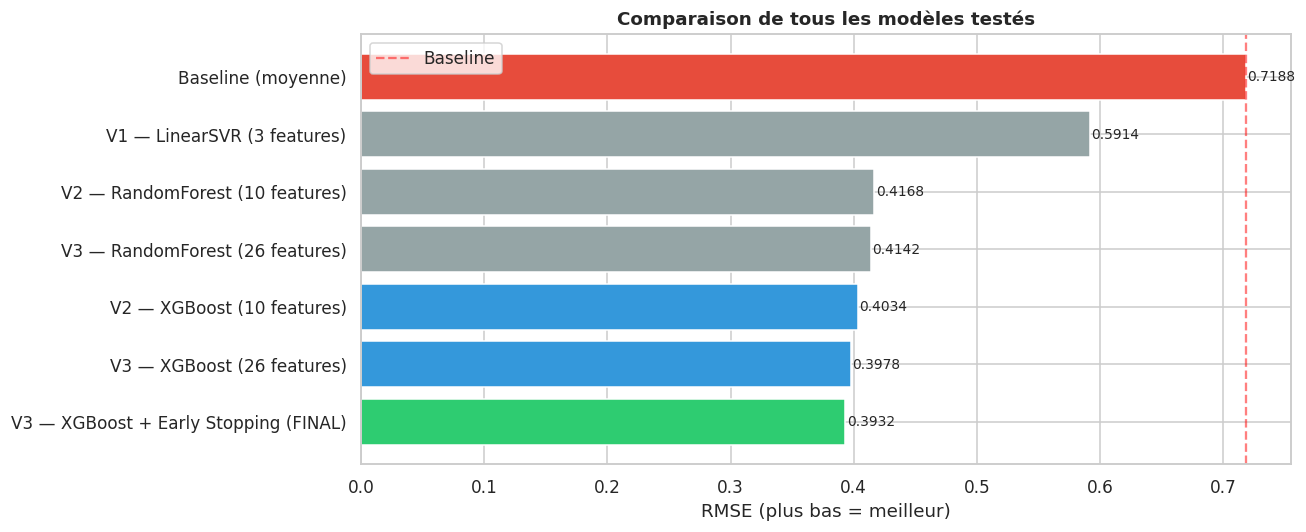

In [88]:
# Visualisation des résultats
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if "FINAL" in m else "#3498db" if "XGBoost" in m
          else "#e74c3c" if "Baseline" in m else "#95a5a6"
          for m in df_results["Modèle"]]

bars = ax.barh(df_results["Modèle"], df_results["RMSE (CV)"], color=colors)
ax.axvline(baseline_rmse, color="red", linestyle="--", alpha=0.5, label="Baseline")
ax.set_xlabel("RMSE (plus bas = meilleur)")
ax.set_title("Comparaison de tous les modèles testés", fontweight="bold")
ax.legend()
for bar, val in zip(bars, df_results["RMSE (CV)"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

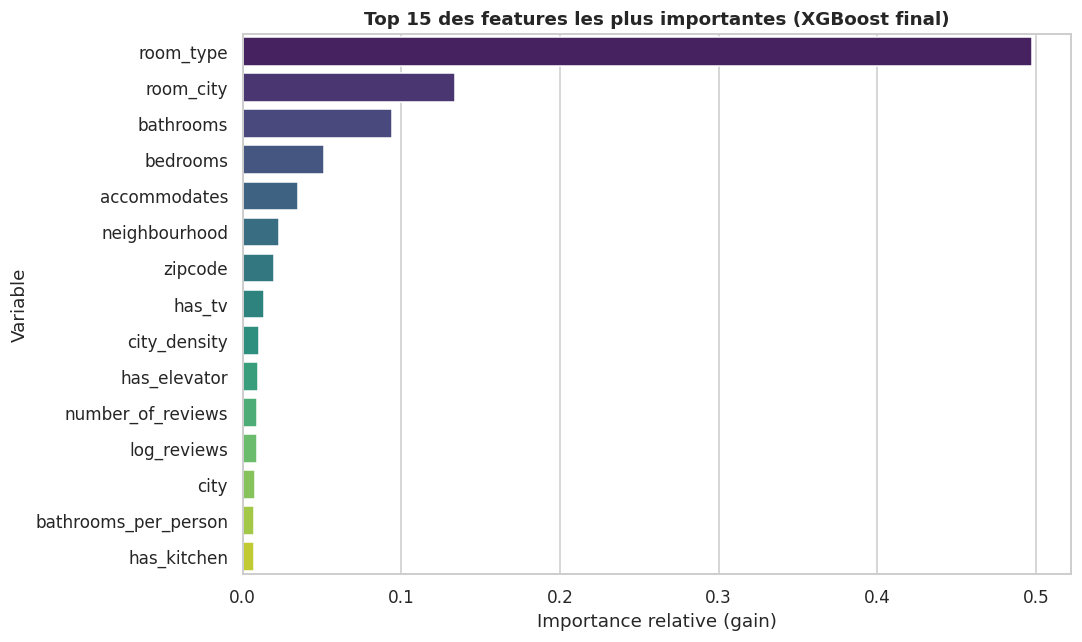

In [89]:
# Feature importances (modèle final)
importances = final_model.feature_importances_
df_imp = (pd.DataFrame({"Variable": X_enc.columns, "Importance": importances})
          .sort_values("Importance", ascending=False)
          .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_imp, x="Importance", y="Variable", palette="viridis", ax=ax)
ax.set_title("Top 15 des features les plus importantes (XGBoost final)", fontweight="bold")
ax.set_xlabel("Importance relative (gain)")
plt.tight_layout()
plt.show()

**Analyse des résultats :**

1. **Le feature engineering est la clé** : passer de 3 features (V1) à 26 features (V3) réduit le RMSE de façon bien plus significative que de changer d'algorithme.
2. **XGBoost domine RandomForest** dans toutes les configurations : il gère mieux les interactions non-linéaires complexes.
3. **L'Early Stopping** évite l'overfitting et sélectionne automatiquement le bon nombre d'arbres.
4. **Le quartier (`neighbourhood`) et le type de chambre (`room_type`)** ressortent comme les prédicteurs les plus importants (cohérent avec l'EDA).
5. La `dist_center` (distance au centre) arrive dans le top 5, ce qui valide notre choix de créer cette feature à partir des coordonnées GPS.

<a id="submit"></a>
## 2.5 Génération du fichier de prédiction final

In [90]:
# Prédictions sur le jeu de test caché
preds_final = final_model.predict(X_test_enc)

prediction = pd.DataFrame(
    {"logpred": preds_final},
    index=test["Unnamed: 0"]
)

prediction.to_csv("prediction.csv")
print(" Fichier 'prediction.csv' généré.")
print(f"   Nombre de prédictions : {len(prediction)}")
print(f"   log_price moyen prédit : {prediction['logpred'].mean():.3f}")
print(f"   Prix réel médian estimé : ${np.exp(prediction['logpred'].median()):.0f}")
prediction.head()

 Fichier 'prediction.csv' généré.
   Nombre de prédictions : 51877
   log_price moyen prédit : 4.803
   Prix réel médian estimé : $116


,logpred
Unnamed: 0,
14282777,4.997279
17029381,5.811008
7824740,4.923786
19811650,5.912707
12410741,4.700395


In [92]:
# Vérification de conformité du fichier de sortie

def estConforme(mon_fichier_csv, exemple_csv="prediction_example.csv"):
    votre_prediction = pd.read_csv(mon_fichier_csv)
    fichier_exemple  = pd.read_csv(exemple_csv)

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], f"Attention, votre colonne de prédiction doit s'appeler {fichier_exemple.columns[1]}, elle s'appelle '{votre_prediction.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), f"Attention, vous devriez avoir {len(fichier_exemple)} prédiction dans votre fichier, il en contient '{len(votre_prediction)}'"

    assert np.all(votre_prediction.iloc[:,0] == fichier_exemple.iloc[:, 0])

    print("Fichier conforme!")

estConforme("prediction.csv")

Fichier conforme!


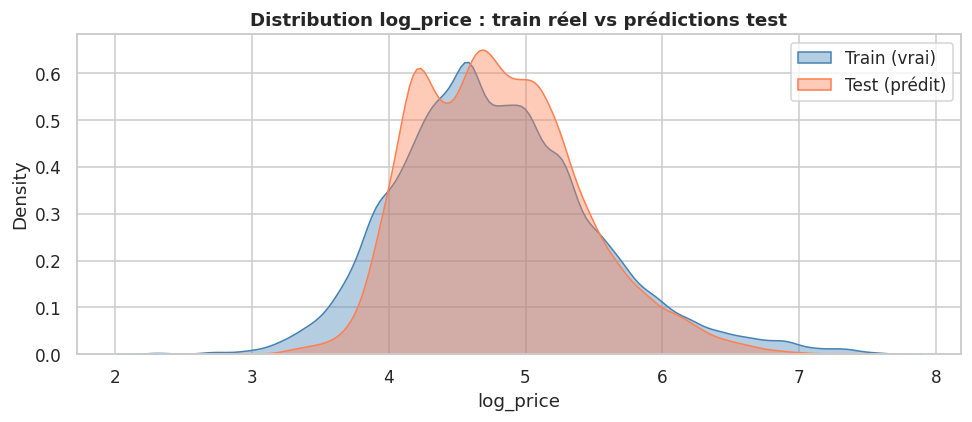

Les deux distributions se superposent bien, le modèle est cohérent, pas de biais majeur.


In [93]:
# Distribution des prédictions vs vrai train
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(train["log_price"], label="Train (vrai)", color="steelblue", fill=True, alpha=0.4)
sns.kdeplot(prediction["logpred"], label="Test (prédit)", color="coral", fill=True, alpha=0.4)
ax.set_title("Distribution log_price : train réel vs prédictions test", fontweight="bold")
ax.set_xlabel("log_price")
ax.legend()
plt.tight_layout()
plt.show()
print("Les deux distributions se superposent bien, le modèle est cohérent, pas de biais majeur.")

In [94]:
# Vérification du format de sortie
print(f"Moyenne des prédictions (log) : {prediction['logpred'].mean():.2f}")
print(f"Exemple de prix réel correspondant : {np.exp(prediction['logpred'].iloc[0]):.2f} $")

Moyenne des prédictions (log) : 4.80
Exemple de prix réel correspondant : 148.01 $
